# 5. Neal's Funnel

The Neal's Funnel distribution is a classic example of a pathological posterior that is difficult to sample from using standard MCMC methods. It is a 10-dimensional hierarchical model where the geometry changes drastically across the parameter space: the top is wide while the bottom narrows into a microscopic neck.

As $v$ becomes negative, the variance of $x$ shrinks exponentially, creating a microscopic "funnel" at the bottom of the space. Standard HMC completely fails here: its fixed step size is either too large to enter the funnel (causing it to miss the tip and bias the variance) or too small to explore the top. NUTS handles this perfectly.

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from scipy.stats import norm

from bml.samplers import nuts, hmc
from bml.distributions.funnel import NealsFunnel
from bml.distributions.counter import GradCounter
from bml import metrics

## Model Definition

Neal's Funnel (Neal, 2003) is a 10-dimensional hierarchical model:

$$v \sim \mathcal{N}(0, 9), \qquad x_i \sim \mathcal{N}(0, e^{v}) \quad \text{for } i = 1, \dots, 9.$$

The log-density is:

$$\log p(v, x) = -\frac{v^2}{18} - \frac{9}{2} v - \frac{e^{-v}}{2} \sum_{i=1}^{9} x_i^2$$

As $v \to -\infty$, the conditional variance $e^v \to 0$, creating a microscopic funnel neck. Standard HMC with a fixed step size either:
- Too large: overshoots the narrow neck, rejecting proposals and biasing the $v$-marginal away from the funnel tip.
- Too small: wastes computation in the wide top of the funnel.

NUTS adapts its trajectory length per iteration, allowing it to handle both regimes.

In [2]:
# Funnel
funnel = NealsFunnel(d=10, sigma_v=3.0)
print(f"Parameter dimension: {funnel.d}")

# Quick gradient check
np.random.seed(42)
theta_test = np.random.randn(funnel.d) * 0.5
analytic_grad = funnel.grad_log_p(theta_test)
numerical_grad = np.zeros_like(theta_test)
eps = 1e-5
for i in range(len(theta_test)):
    e = np.zeros_like(theta_test)
    e[i] = eps
    numerical_grad[i] = (
        funnel.log_p(theta_test + e) - funnel.log_p(theta_test - e)
    ) / (2 * eps)

rel_err = np.linalg.norm(analytic_grad - numerical_grad) / (
    np.linalg.norm(analytic_grad) + 1e-10
)
print(f"Gradient check — relative error: {rel_err:.2e}")
assert rel_err < 1e-4, f"Gradient check failed with relative error {rel_err:.2e}"
print("Gradient check passed.")

Parameter dimension: 10
Gradient check — relative error: 5.14e-12
Gradient check passed.


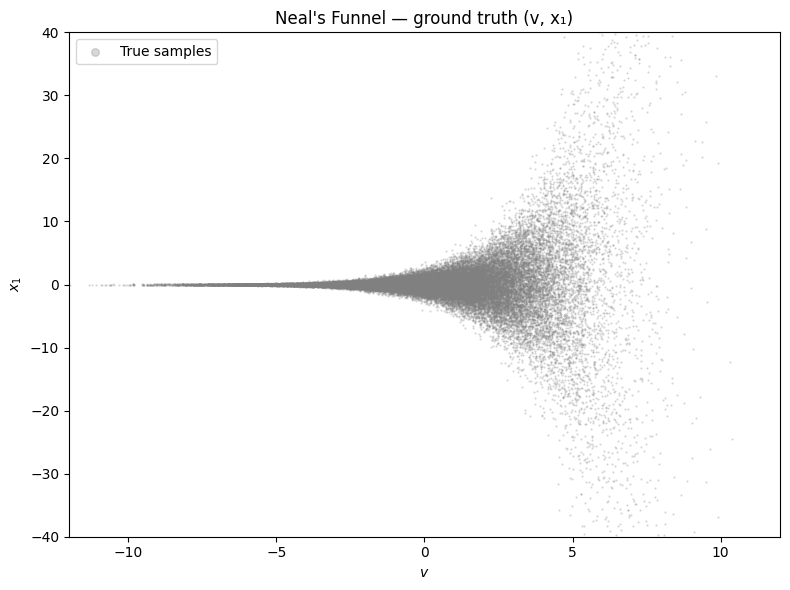

In [3]:
# Ground-truth samples
np.random.seed(0)
N_true = 50000
v_true = np.random.normal(0, 3.0, size=N_true)
x_true = np.random.normal(0, 1, size=(N_true, 9)) * np.exp(v_true / 2)[:, None]
true_samples = np.column_stack([v_true, x_true])

# Visualization
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(
    true_samples[:, 0],
    true_samples[:, 1],
    s=0.3,
    alpha=0.3,
    color="gray",
    label="True samples",
)
ax.set_xlabel("$v$")
ax.set_ylabel("$x_1$")
ax.set_title("Neal's Funnel — ground truth (v, x₁)")
ax.set_xlim(-12, 12)
ax.set_ylim(-40, 40)
ax.legend(markerscale=10)
plt.tight_layout()
plt.savefig("../results/Funnel/ground_truth_funnel.png", dpi=150, bbox_inches="tight")
plt.show()

## Sampling: NUTS vs HMC

We run both Dual-Averaging NUTS and Dual-Averaging HMC on the funnel. The key question is whether each sampler can explore both the wide top ($v > 0$) and the narrow neck ($v < 0$) of the funnel. HMC's fixed trajectory length is expected to struggle severely.

In [4]:
np.random.seed(0)

theta0 = np.zeros(funnel.d)  # Start at origin
M = 20_000  # Total iterations
M_adapt = 5_000  # Warmup / adaptation iterations
delta = 0.95  # Target acceptance rate
# Notes
# We use a higher delta to encourage smaller step sizes, which can help with stability in this challenging distribution. 
# We also increase the maximum depth for NUTS to 15 to allow for more exploration per iteration, which can be beneficial in the funnel's geometry.

results = {}
all_samples = {}
all_stats = {}

for sampler_name, SamplerClass in [
    ("Dual Averaging NUTS", nuts.DualAveragingNUTS),
    ("Dual Averaging HMC", hmc.DualAveragingHMC),
]:
    print(f"\n{'=' * 60}")
    print(f"Starting {sampler_name} sampling for Neal's Funnel")

    model = GradCounter(funnel)
    sampler = SamplerClass(L=model.log_p, grad=model.grad)

    if sampler_name == "Dual Averaging HMC":
        samples, stats = sampler.sample(
            theta0.copy(), delta=delta, lam=1.0, M=M, M_adapt=M_adapt
        )
    else:
        samples, stats = sampler.sample(
            theta0.copy(), delta=delta, M=M, M_adapt=M_adapt
        )

    print(f"Finished {sampler_name}. Output shape: {samples.shape}")
    print(f"Total gradient evaluations: {model.count}")

    valid_samples = samples[M_adapt:]

    # Compute worst-case ESS across all dimensions
    sample_means = np.mean(valid_samples, axis=0)
    sample_vars = np.var(valid_samples, axis=0)

    min_ess = float("inf")
    for dim in range(funnel.d):
        dim_samples = valid_samples[:, dim]
        mu = sample_means[dim]
        var = sample_vars[dim]
        if var < 1e-12:
            continue

        ess_mean = metrics.compute_ess_1d(dim_samples, mu, var)

        moment_samples = (dim_samples - mu) ** 2
        moment_mu = np.mean(moment_samples)
        moment_var = np.var(moment_samples)
        if moment_var > 1e-12:
            ess_variance = metrics.compute_ess_1d(moment_samples, moment_mu, moment_var)
            min_ess = min(min_ess, ess_mean, ess_variance)
        else:
            min_ess = min(min_ess, ess_mean)

    ess_per_grad = min_ess / model.count
    results[sampler_name] = {
        "min_ess": min_ess,
        "grad_evals": model.count,
        "ess_per_grad": ess_per_grad,
    }
    all_samples[sampler_name] = samples
    all_stats[sampler_name] = stats

    print(f"Worst-case ESS: {min_ess:.4f}")
    print(f"ESS / gradient: {ess_per_grad:.6f}")


Starting Dual Averaging NUTS sampling for Neal's Funnel
Finished Dual Averaging NUTS. Output shape: (20001, 10)
Total gradient evaluations: 3284872
Worst-case ESS: 182.4998
ESS / gradient: 0.000056

Starting Dual Averaging HMC sampling for Neal's Funnel
Finished Dual Averaging HMC. Output shape: (20001, 10)
Total gradient evaluations: 230114
Worst-case ESS: 37.7699
ESS / gradient: 0.000164


In [5]:
# Summary table
summary_df = pd.DataFrame(results).T
summary_df.columns = ["Worst-case ESS", "Gradient Evaluations", "ESS / Gradient"]
print(summary_df.to_string())

                     Worst-case ESS  Gradient Evaluations  ESS / Gradient
Dual Averaging NUTS      182.499847             3284872.0        0.000056
Dual Averaging HMC        37.769886              230114.0        0.000164


## Diagnostics

### 1. Funnel scatter plots — NUTS vs HMC vs ground truth

The most revealing diagnostic: overlay sampler output on the true $(v, x_1)$ funnel. A good sampler fills the entire funnel, including the narrow neck at $v \ll 0$.

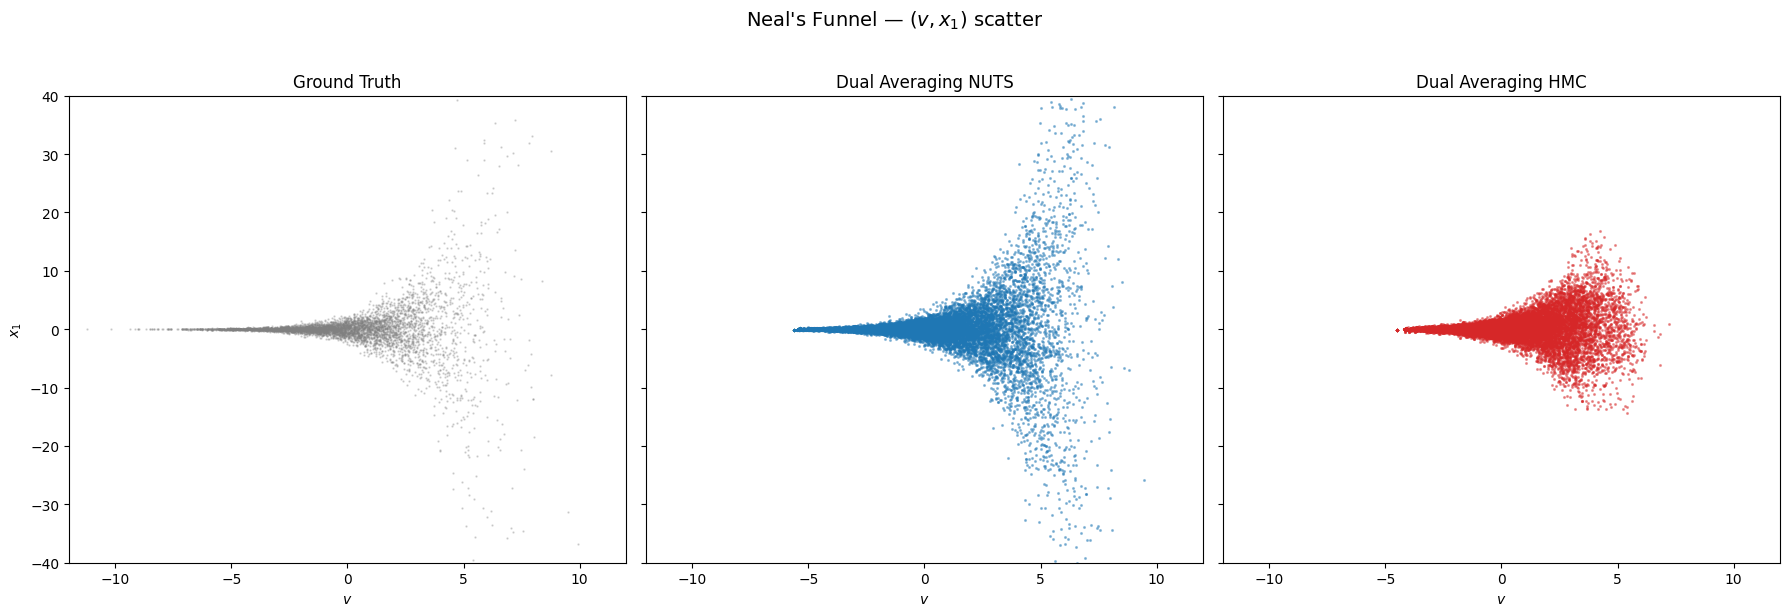

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

# Ground truth
axes[0].scatter(
    true_samples[:5000, 0], true_samples[:5000, 1], s=0.5, alpha=0.3, color="gray"
)
axes[0].set_title("Ground Truth")
axes[0].set_xlabel("$v$")
axes[0].set_ylabel("$x_1$")
axes[0].set_xlim(-12, 12)
axes[0].set_ylim(-40, 40)

for idx, (name, samples) in enumerate(all_samples.items()):
    valid = samples[M_adapt:]
    color = "tab:blue" if "NUTS" in name else "tab:red"
    axes[idx + 1].scatter(valid[:, 0], valid[:, 1], s=1.5, alpha=0.4, color=color)
    axes[idx + 1].set_title(name)
    axes[idx + 1].set_xlabel("$v$")
    axes[idx + 1].set_xlim(-12, 12)

plt.suptitle("Neal's Funnel — $(v, x_1)$ scatter", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../results/Funnel/funnel_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

### 2. Marginal distribution of $v$

The true marginal is $v \sim \mathcal{N}(0, 9)$. If HMC fails to enter the narrow funnel neck, its $v$-marginal will be biased away from negative values.

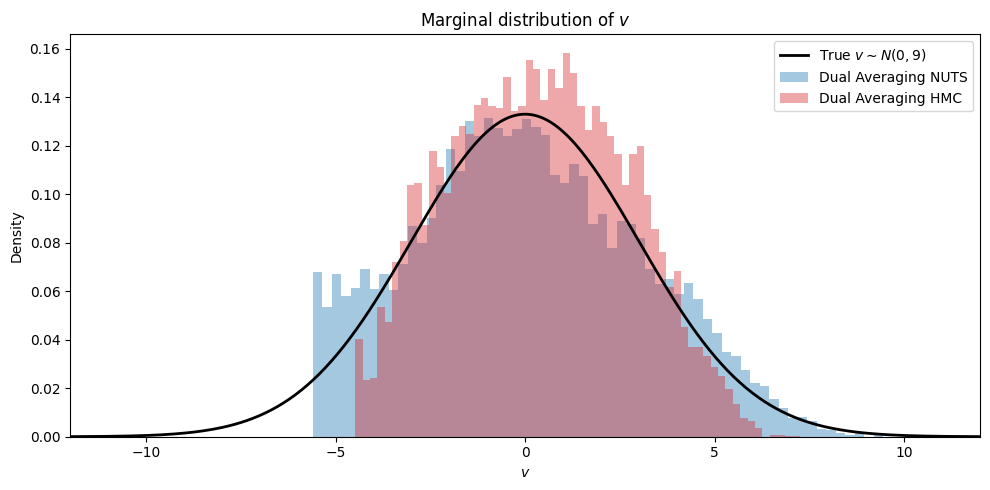

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

# True marginal
v_grid = np.linspace(-12, 12, 300)
ax.plot(v_grid, norm.pdf(v_grid, 0, 3), "k-", lw=2, label="True $v \\sim N(0, 9)$")

for name, samples in all_samples.items():
    valid = samples[M_adapt:]
    color = "tab:blue" if "NUTS" in name else "tab:red"
    ax.hist(valid[:, 0], bins=60, density=True, alpha=0.4, color=color, label=name)

ax.set_xlabel("$v$")
ax.set_ylabel("Density")
ax.set_title("Marginal distribution of $v$")
ax.legend()
ax.set_xlim(-12, 12)
plt.tight_layout()
plt.savefig("../results/Funnel/v_marginal.png", dpi=150, bbox_inches="tight")
plt.show()

### 3. Step-size adaptation and acceptance statistics

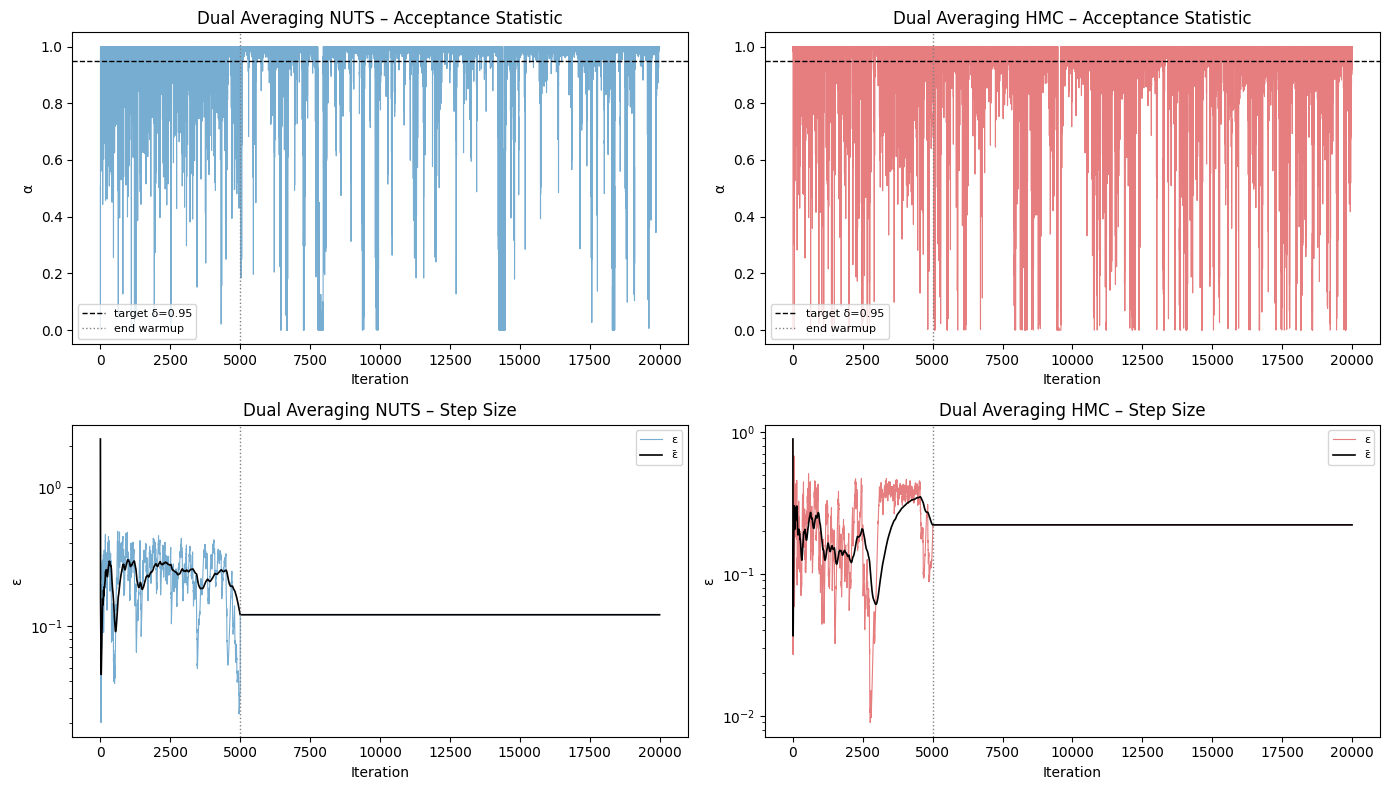

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for idx, (name, stats) in enumerate(all_stats.items()):
    color = "tab:blue" if "NUTS" in name else "tab:red"

    # Acceptance statistic
    axes[0, idx].plot(stats["h_stat"], alpha=0.6, color=color, lw=0.8)
    axes[0, idx].axhline(delta, color="black", ls="--", lw=1, label=f"target δ={delta}")
    axes[0, idx].axvline(M_adapt, color="gray", ls=":", lw=1, label="end warmup")
    axes[0, idx].set_title(f"{name} – Acceptance Statistic")
    axes[0, idx].set_xlabel("Iteration")
    axes[0, idx].set_ylabel("α")
    axes[0, idx].legend(fontsize=8)

    # Step size
    axes[1, idx].plot(stats["epsilon"], alpha=0.6, color=color, lw=0.8, label="ε")
    axes[1, idx].plot(stats["epsilon_bar"], color="black", lw=1.2, label="ε̄")
    axes[1, idx].axvline(M_adapt, color="gray", ls=":", lw=1)
    axes[1, idx].set_title(f"{name} – Step Size")
    axes[1, idx].set_xlabel("Iteration")
    axes[1, idx].set_ylabel("ε")
    axes[1, idx].legend(fontsize=8)
    axes[1, idx].set_yscale("log")

plt.tight_layout()
plt.savefig(
    "../results/Funnel/adaptation_diagnostics.png", dpi=150, bbox_inches="tight"
)
plt.show()

### 4. Trace plots ($v$ and selected $x_i$)

Trace plots reveal whether the chain transitions between the wide top and narrow neck of the funnel.

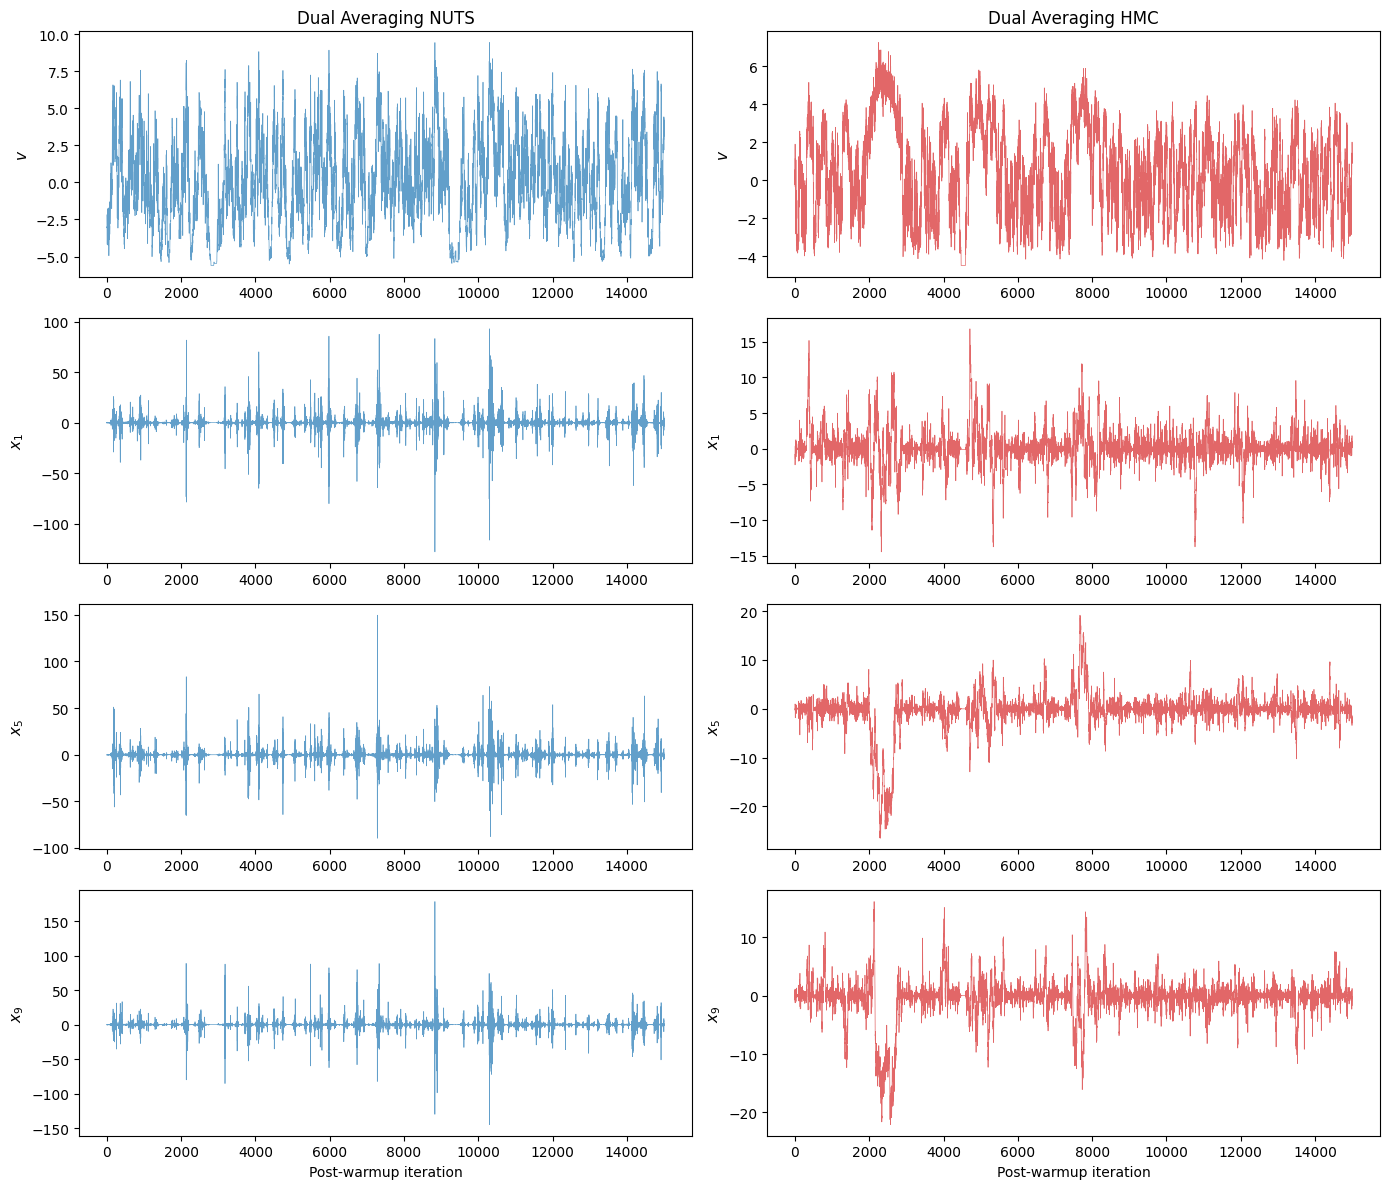

In [9]:
dims_to_plot = [0, 1, 5, 9]
dim_labels = ["$v$", "$x_1$", "$x_5$", "$x_9$"]

fig, axes = plt.subplots(len(dims_to_plot), 2, figsize=(14, 3 * len(dims_to_plot)))

for row, (dim, label) in enumerate(zip(dims_to_plot, dim_labels)):
    for col, name in enumerate(all_samples.keys()):
        samples = all_samples[name]
        color = "tab:blue" if "NUTS" in name else "tab:red"
        axes[row, col].plot(samples[M_adapt:, dim], alpha=0.7, lw=0.5, color=color)
        axes[row, col].set_ylabel(label, fontsize=11)
        if row == 0:
            axes[row, col].set_title(name, fontsize=12)
        if row == len(dims_to_plot) - 1:
            axes[row, col].set_xlabel("Post-warmup iteration")

plt.tight_layout()
plt.savefig("../results/Funnel/trace_plots.png", dpi=150, bbox_inches="tight")
plt.show()

### 5. Log-posterior over iterations

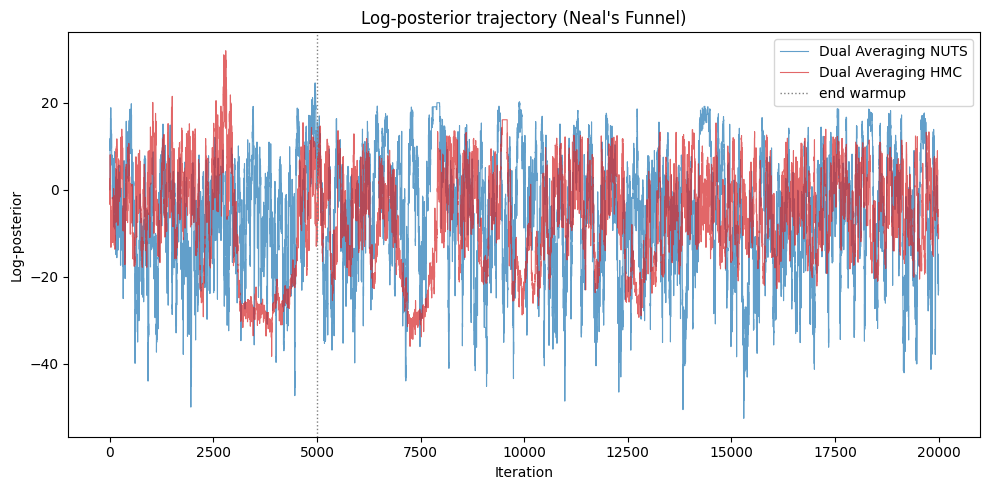

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

for name, samples in all_samples.items():
    color = "tab:blue" if "NUTS" in name else "tab:red"
    log_posts = [funnel.log_p(samples[i]) for i in range(len(samples))]
    ax.plot(log_posts, alpha=0.7, lw=0.8, color=color, label=name)

ax.axvline(M_adapt, color="gray", ls=":", lw=1, label="end warmup")
ax.set_xlabel("Iteration")
ax.set_ylabel("Log-posterior")
ax.set_title("Log-posterior trajectory (Neal's Funnel)")
ax.legend()
plt.tight_layout()
plt.savefig("../results/Funnel/log_posterior.png", dpi=150, bbox_inches="tight")
plt.show()

### 6. Trajectory lengths (NUTS adaptive vs HMC fixed)

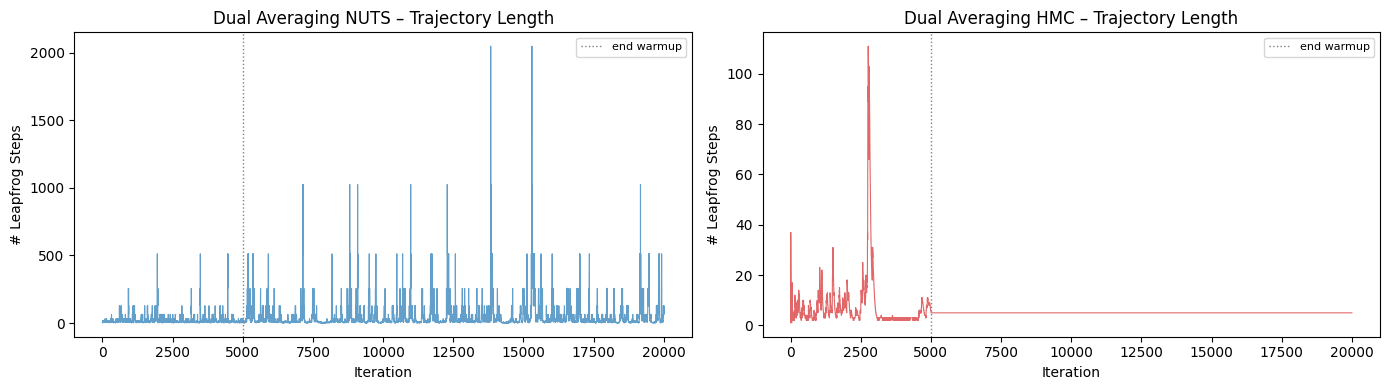

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=False)

for idx, (name, stats) in enumerate(all_stats.items()):
    color = "tab:blue" if "NUTS" in name else "tab:red"
    axes[idx].plot(stats["trajectory_length"], alpha=0.7, lw=0.8, color=color)
    axes[idx].set_title(f"{name} – Trajectory Length")
    axes[idx].set_xlabel("Iteration")
    axes[idx].set_ylabel("# Leapfrog Steps")
    axes[idx].axvline(M_adapt, color="gray", ls=":", lw=1, label="end warmup")
    axes[idx].legend(fontsize=8)

plt.tight_layout()
plt.savefig("../results/Funnel/trajectory_lengths.png", dpi=150, bbox_inches="tight")
plt.show()

### 7. Quantitative comparison against ground truth

Since we have exact ground-truth moments, we can directly measure bias in the estimated $\text{Var}(v)$ and $\mathbb{E}[e^v]$ (the mean conditional variance of $x_i$).

In [12]:
# True moments
true_var_v = 9.0
true_E_exp_v = np.exp(0.5 * true_var_v)

print(f"{'':30s}  {'Var(v)':>10s}  {'E[exp(v)]':>12s}")
print(f"{'True':30s}  {true_var_v:10.4f}  {true_E_exp_v:12.4f}")
print("-" * 58)

for name, samples in all_samples.items():
    valid = samples[M_adapt:]
    v_samples = valid[:, 0]

    est_var_v = np.var(v_samples)
    est_E_exp_v = np.mean(np.exp(np.clip(v_samples, -50, 50)))

    print(f"{name:30s}  {est_var_v:10.4f}  {est_E_exp_v:12.4f}")


                                    Var(v)     E[exp(v)]
True                                9.0000       90.0171
----------------------------------------------------------
Dual Averaging NUTS                 8.9406       46.3864
Dual Averaging HMC                  5.3509       13.3484


## NUTS Efficiency across $\delta$

Sweep the target acceptance rate $\delta$ for NUTS and measure ESS per gradient evaluation.

In [13]:
deltas = np.linspace(0.3, 0.9, 7)
results_delta = []

for d_val in deltas:
    print(f"Sampling for delta={d_val:.2f}...")

    model = GradCounter(funnel)
    sampler = nuts.DualAveragingNUTS(L=model.log_p, grad=model.grad)

    theta_init = np.zeros(funnel.d)
    samples, stats = sampler.sample(theta_init, delta=d_val, M=M, M_adapt=M_adapt)

    valid_samples = samples[M_adapt:]
    sample_means = np.mean(valid_samples, axis=0)
    sample_vars = np.var(valid_samples, axis=0)

    min_ess = float("inf")
    for dim in range(funnel.d):
        dim_samples = valid_samples[:, dim]
        mu = sample_means[dim]
        var = sample_vars[dim]
        if var < 1e-12:
            continue
        ess_mean = metrics.compute_ess_1d(dim_samples, mu, var)

        moment_samples = (dim_samples - mu) ** 2
        moment_mu = np.mean(moment_samples)
        moment_var = np.var(moment_samples)
        if moment_var > 1e-12:
            ess_variance = metrics.compute_ess_1d(moment_samples, moment_mu, moment_var)
            min_ess = min(min_ess, ess_mean, ess_variance)
        else:
            min_ess = min(min_ess, ess_mean)

    total_grads = model.count
    ess_per_grad = min_ess / total_grads
    results_delta.append((d_val, min_ess, total_grads, ess_per_grad))
    print(
        f"  δ={d_val:.2f}  |  ESS={min_ess:.4f}  |  Grads={total_grads}  |  ESS/grad={ess_per_grad:.6f}\n"
    )

results_delta_df = pd.DataFrame(
    results_delta,
    columns=["Delta", "Worst-case ESS", "Total Gradients", "ESS per Gradient"],
)
results_delta_df.to_csv("../results/Funnel/DANUTS_delta.csv", index=False)
print(results_delta_df.to_string(index=False))

Sampling for delta=0.30...
  δ=0.30  |  ESS=104.4073  |  Grads=339518  |  ESS/grad=0.000308

Sampling for delta=0.40...
  δ=0.40  |  ESS=159.3264  |  Grads=589652  |  ESS/grad=0.000270

Sampling for delta=0.50...
  δ=0.50  |  ESS=49.5429  |  Grads=735202  |  ESS/grad=0.000067

Sampling for delta=0.60...
  δ=0.60  |  ESS=159.0121  |  Grads=1164140  |  ESS/grad=0.000137

Sampling for delta=0.70...
  δ=0.70  |  ESS=277.6101  |  Grads=1188526  |  ESS/grad=0.000234

Sampling for delta=0.80...
  δ=0.80  |  ESS=5.4968  |  Grads=818612  |  ESS/grad=0.000007

Sampling for delta=0.90...
  δ=0.90  |  ESS=248.5599  |  Grads=1679880  |  ESS/grad=0.000148

 Delta  Worst-case ESS  Total Gradients  ESS per Gradient
   0.3      104.407323           339518          0.000308
   0.4      159.326418           589652          0.000270
   0.5       49.542859           735202          0.000067
   0.6      159.012100          1164140          0.000137
   0.7      277.610068          1188526          0.000234
 

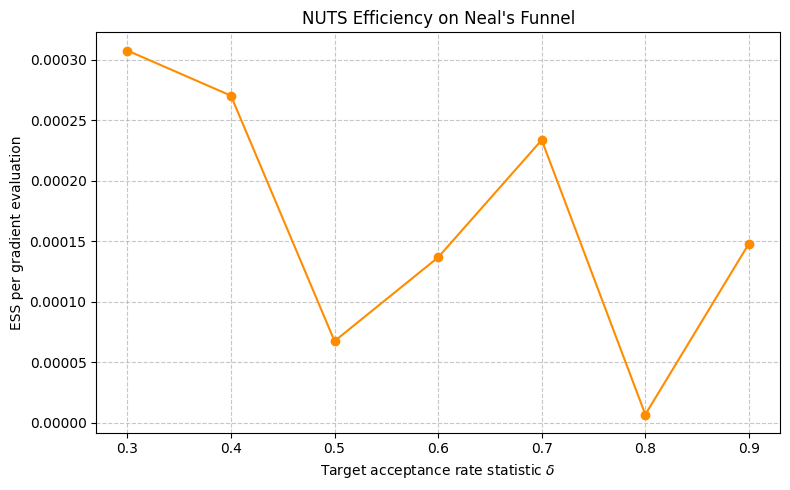

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(
    results_delta_df["Delta"],
    results_delta_df["ESS per Gradient"],
    marker="o",
    linestyle="-",
    color="darkorange",
)
plt.xlabel("Target acceptance rate statistic $\\delta$")
plt.ylabel("ESS per gradient evaluation")
plt.title("NUTS Efficiency on Neal's Funnel")
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.savefig(
    "../results/Funnel/Funnel_efficiency_plot.png", dpi=150, bbox_inches="tight"
)
plt.show()

## Summary

The funnel's geometry changes drastically across the parameter space. At the top ($v > 0$), the $x_i$ have large variance and the sampler needs big steps. At the bottom ($v \ll 0$), the $x_i$ are confined to a microscopic tube and need tiny steps. No single fixed step size can handle both regimes.

Key observations:
- NUTS adapts its trajectory length at each iteration, which allows it to take short, careful trajectories when deep in the narrow funnel neck and long, sweeping trajectories in the wide top. This produces samples that faithfully cover the entire funnel.
- HMC with a fixed trajectory length (and a single adapted step size) is forced to compromise. Its step size typically settles to a value suitable for the wide top, causing divergent transitions and rejections when it tries to enter the narrow neck. The result is a biased $v$-marginal that fails to properly explore negative values.
- The marginal distribution of $v$ provides an informative diagnostic: it should match $\mathcal{N}(0, 9)$. HMC's histogram is truncated on the left.
- Var($v$) and $\mathbb{E}[e^v]$ provide quantitative bias measures against known ground truth.
- This problem is a canonical example of why adaptive trajectory-length methods like NUTS are essential for hierarchical Bayesian models, where the geometry of the posterior changes across the parameter space.